<a href="https://colab.research.google.com/github/mariocarrasco03/Practicas_redes_neuronales_Mario_Carrasco/blob/main/PRACTICA_03_Regresion_con_MLP__MARIO_CARRASCOipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="darkorange" size="10"><b>03. Regresión con MLP</b></font>

Mario Carrasco Martínez

Correo: marioc19@ucm.es

# Ejercicio 01.
Con los datos de este ejemplo crea una red neuronal que sea capaz de generar un error de cero (es decir, la linea de MLP atraviesa todos los puntos).

In [ ]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

In [ ]:
X = np.array(
    [258.0, 270.0, 294.0, 320.0, 342.0, 368.0, 396.0, 446.0, 480.0, 586.0]
)[:, np.newaxis]

y = np.array(
    [236.4, 234.4, 252.8, 298.6, 314.2, 342.2, 360.8, 368.0, 391.2, 390.8]
)

In [ ]:
print(X)
print(y)

[[258.]
 [270.]
 [294.]
 [320.]
 [342.]
 [368.]
 [396.]
 [446.]
 [480.]
 [586.]]
[236.4 234.4 252.8 298.6 314.2 342.2 360.8 368.  391.2 390.8]


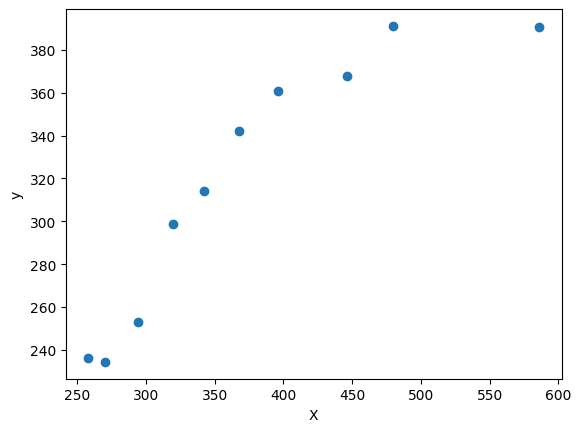

In [ ]:
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)


X_range = np.arange(250, 600, 10)[:, np.newaxis]
y_linear = lr.predict(X_range)

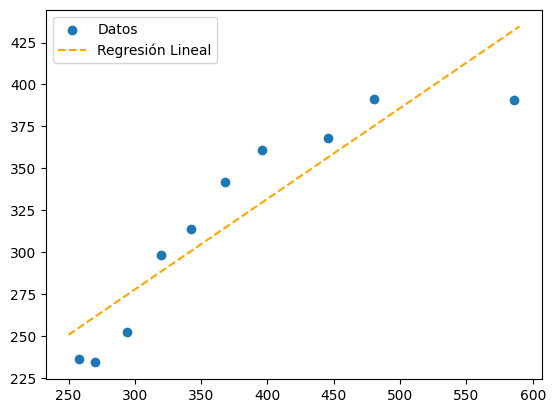

In [ ]:
plt.scatter(X, y, label="Datos")
plt.plot(X_range, y_linear, label="Regresión Lineal", linestyle="--", color="orange")
plt.legend()
plt.show()

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Normalizamos X e y
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Pasamos las variables a tensores
tensor_X = torch.Tensor(X_norm) # transform to torch tensor
tensor_y = torch.Tensor(y_norm)

# Creamos el dataset y el dataloader
my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, X_nvars):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Hidden Layer 1
            torch.nn.Linear(X_nvars, 200),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(200, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output

In [ ]:
# Fijamos la semilla a un valor para que los resultados sean identicos
torch.manual_seed(1)

# Ahora fijamos algunos hiper-parámetros

# Creamos el modelo MLP
model = MLP(X_nvars=1)

# Definimos la función loss
loss_fn = torch.nn.MSELoss()

# Elegimos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
import torch.nn.functional as F


num_epochs = 2500


loss_history = []

for epoch in range(num_epochs):
    model = model.train()


    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)
        loss = loss_fn(output, targets.view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )

    loss_history.append(loss.item())

Epoch: 001/2500 | Batch 000/010 | Train Loss: 2.63
Epoch: 002/2500 | Batch 000/010 | Train Loss: 3.77
Epoch: 003/2500 | Batch 000/010 | Train Loss: 1.27
Epoch: 004/2500 | Batch 000/010 | Train Loss: 0.35
Epoch: 005/2500 | Batch 000/010 | Train Loss: 0.06
Epoch: 006/2500 | Batch 000/010 | Train Loss: 0.00
Epoch: 007/2500 | Batch 000/010 | Train Loss: 0.01
Epoch: 008/2500 | Batch 000/010 | Train Loss: 0.04
Epoch: 009/2500 | Batch 000/010 | Train Loss: 0.07
Epoch: 010/2500 | Batch 000/010 | Train Loss: 0.09
Epoch: 011/2500 | Batch 000/010 | Train Loss: 0.10
Epoch: 012/2500 | Batch 000/010 | Train Loss: 0.10
Epoch: 013/2500 | Batch 000/010 | Train Loss: 0.11
Epoch: 014/2500 | Batch 000/010 | Train Loss: 0.11
Epoch: 015/2500 | Batch 000/010 | Train Loss: 0.10
Epoch: 016/2500 | Batch 000/010 | Train Loss: 0.10
Epoch: 017/2500 | Batch 000/010 | Train Loss: 0.10
Epoch: 018/2500 | Batch 000/010 | Train Loss: 0.10
Epoch: 019/2500 | Batch 000/010 | Train Loss: 0.10
Epoch: 020/2500 | Batch 000/010

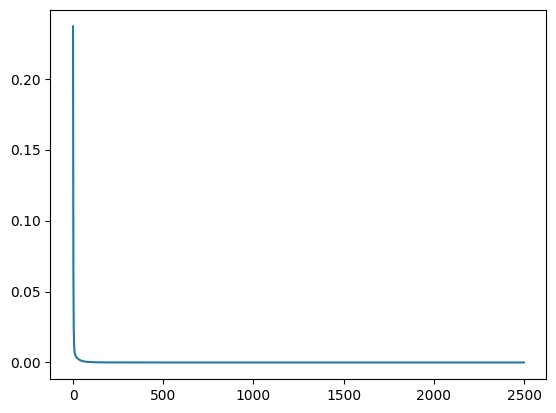

In [ ]:
plt.plot(loss_history)

In [ ]:
model.eval() # se fijan parametros del modelo para evaluar

# predecimos los valores del rango X_range segun el MLP

# Se pasan a un tensor normalizado
X_range_norm = (X_range - x_mean) / x_std
X_range_norm = torch.tensor(X_range_norm, dtype=torch.float32)

# Se meten en el modelo
y_mlp_norm = model(X_range_norm)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp_norm = y_mlp_norm.detach().numpy().astype(np.float64) # dejan de ser un tensor
y_mlp = y_mlp_norm * y_std + y_mean # desnormalizan


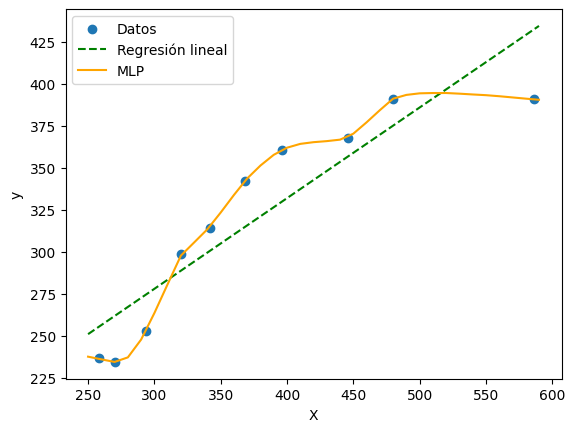

In [ ]:
# Vamos a hacer un plot con los resultados

# Los datos originales
plt.scatter(X, y, label="Datos")

# Los datos predichos por la regresion lineal
plt.plot(X_range, y_linear, label="Regresión lineal", linestyle="--", color='green')

# Los datos predichos por el MLP
plt.plot(X_range, y_mlp, label="MLP", color='orange')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

#Ejercicio 02.
Usando el código siguiente, construye un MLP que se ajuste razonablemente a los puntos de ese seno. Puedes jugar con la creación de datos.

In [ ]:
%reset -f

In [ ]:
# Importamos las librerias que vamos a necesitar

import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

(100,)
(100,)


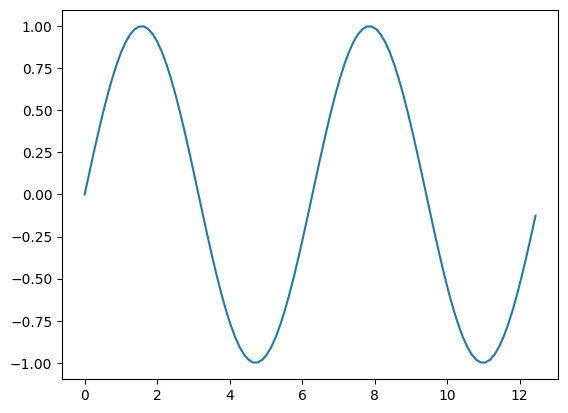

In [ ]:
# Creamos los datos, en este caso un seno

import numpy as np

cycles = 2  # numero de periodos
n = 100     # numero de datos en x

length = 2 * np.pi * cycles

X = np.arange(0, length, length / n)
y = np.sin(X)

plt.plot(X, y, '-')

print(X.shape)
print(y.shape)

In [ ]:
# preparamos los datos

from torch.utils.data import TensorDataset, DataLoader

# Normalizamos X e y
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std

X_norm = X_norm.reshape(-1, 1)
y_norm = y_norm.reshape(-1, 1)

# Pasamos las variables a tensores
tensor_X = torch.Tensor(X_norm) # transform to torch tensor
tensor_y = torch.Tensor(y_norm)

# Creamos el dataset y el dataloader
my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:



class MLP(torch.nn.Module):
    def __init__(self, X_nvars):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Hidden Layer 1
            torch.nn.Linear(X_nvars, 300),
            torch.nn.ReLU(),

            # Hidden Layer 2
            torch.nn.Linear(300, 300),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(300, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output

In [ ]:
torch.manual_seed(1)


# Creamos el modelo MLP
model = MLP(X_nvars=1)

# Definimos la función loss
loss_fn = torch.nn.MSELoss()

# Elegimos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [ ]:
import torch.nn.functional as F

# Fijamos el número de épocas o iteraciones
num_epochs = 5000

# Una variables donde vamos a ir guardando los valores del loss para ploterarlos
loss_history = []

for epoch in range(num_epochs):
    model = model.train() # se fijan algunas cosas para hacer entrenamiento


    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)
        loss = loss_fn(output, targets)     # Calculamos el loss

        optimizer.zero_grad()        # Ponemos a cero el gradiente
        loss.backward()              # Calculamos los gradientes (la derivada del loss)
        optimizer.step()             # Cambiamos los pesos de la red


        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )

    loss_history.append(loss.item())

Epoch: 001/5000 | Batch 000/100 | Train Loss: 0.00
Epoch: 002/5000 | Batch 000/100 | Train Loss: 0.17
Epoch: 003/5000 | Batch 000/100 | Train Loss: 0.21
Epoch: 004/5000 | Batch 000/100 | Train Loss: 0.37
Epoch: 005/5000 | Batch 000/100 | Train Loss: 0.51
Epoch: 006/5000 | Batch 000/100 | Train Loss: 0.52
Epoch: 007/5000 | Batch 000/100 | Train Loss: 0.37
Epoch: 008/5000 | Batch 000/100 | Train Loss: 0.22
Epoch: 009/5000 | Batch 000/100 | Train Loss: 0.07
Epoch: 010/5000 | Batch 000/100 | Train Loss: 0.00
Epoch: 011/5000 | Batch 000/100 | Train Loss: 0.07
Epoch: 012/5000 | Batch 000/100 | Train Loss: 0.07
Epoch: 013/5000 | Batch 000/100 | Train Loss: 0.22
Epoch: 014/5000 | Batch 000/100 | Train Loss: 0.85
Epoch: 015/5000 | Batch 000/100 | Train Loss: 0.11
Epoch: 016/5000 | Batch 000/100 | Train Loss: 4.97
Epoch: 017/5000 | Batch 000/100 | Train Loss: 2.00
Epoch: 018/5000 | Batch 000/100 | Train Loss: 2.14
Epoch: 019/5000 | Batch 000/100 | Train Loss: 2.21
Epoch: 020/5000 | Batch 000/100

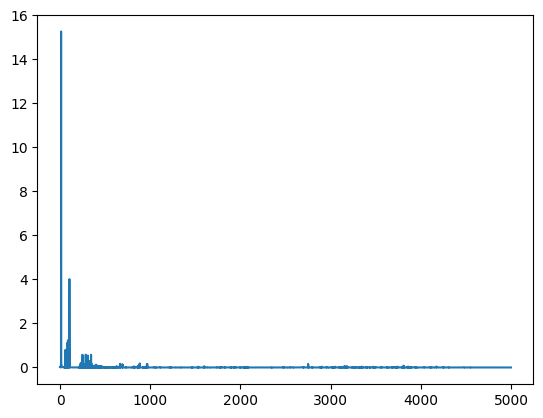

In [ ]:

plt.plot(loss_history)

In [ ]:
# Vamos a evaluar el funcionamiento del modelo

model.eval() # se fijan parametros del modelo para evaluar


# Se pasan a un tensor normalizado
X_range_norm = (X - x_mean) / x_std
X_range_norm = torch.tensor(X_range_norm[:, np.newaxis], dtype=torch.float32)

# Se meten en el modelo
y_mlp_norm = model(X_range_norm)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp_norm = y_mlp_norm.detach().numpy().astype(np.float64) # dejan de ser un tensor
y_mlp = y_mlp_norm * y_std + y_mean # desnormalizan


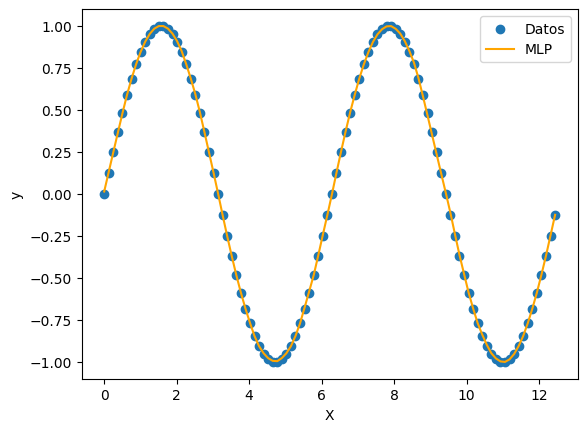

In [ ]:
plt.scatter(X, y, label="Datos")

plt.plot(X, y_mlp, label="MLP", color='orange')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Ejercicio 03

Regresión con datos de felicidad

Se analizan unos datos obtenido de Kaggle.com sobre la encuesta de felicidad de 2021: [enlace](https://https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2021)

Una vez limpiados y preparados la base de datos consta de 9 variables predictoras y una variable criterio:

**Criterio**: Life.Ladder.

**Predictoras**: year, Log.GDP.per.capita, Social.support, Healthy.life.expectancy.at.birth, Freedom.to.make.life.choices, Generosity, Perceptions.of.corruption, Positive.affect, Negative.affect.


In [ ]:
%reset -f

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

In [ ]:
# Funciones para importar y preparar los datos

import pandas as pd
url = 'https://raw.githubusercontent.com/mcstllns/UNIR2024/main/data-happiness.csv'
data  = pd.read_csv(url)
print(data.keys())
data.head()

# El fichero tiene datos perdidos y hay que eliminar las filas
data = data.dropna()

# Creamos conjuntos X e y
X = data.drop('Life.Ladder', axis=1)
y = data['Life.Ladder']

print(X.head())
print(y.head())


Index(['year', 'Life.Ladder', 'Log.GDP.per.capita', 'Social.support',
       'Healthy.life.expectancy.at.birth', 'Freedom.to.make.life.choices',
       'Generosity', 'Perceptions.of.corruption', 'Positive.affect',
       'Negative.affect'],
      dtype='object')
   year  Log.GDP.per.capita  Social.support  Healthy.life.expectancy.at.birth  \
0  2008               7.370           0.451                             50.80   
1  2009               7.540           0.552                             51.20   
2  2010               7.647           0.539                             51.60   
3  2011               7.620           0.521                             51.92   
4  2012               7.705           0.521                             52.24   

   Freedom.to.make.life.choices  Generosity  Perceptions.of.corruption  \
0                         0.718       0.168                      0.882   
1                         0.679       0.190                      0.850   
2                         0.

In [ ]:
# preparamos los datos

from torch.utils.data import TensorDataset, DataLoader

# Normalizamos X e y
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std


tensor_X = torch.from_numpy(X_norm.values).float()
tensor_y = torch.from_numpy(y_norm.values).float()

my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset) # create your dataloader

In [ ]:
print(tensor_X.shape)
print(tensor_y.shape)

torch.Size([1708, 9])
torch.Size([1708])


In [ ]:

class MLP(torch.nn.Module):
    def __init__(self, X_nvars):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Hidden Layer 1
            torch.nn.Linear(X_nvars, 700),
            torch.nn.ReLU(),

            # Hidden Layer 2
            torch.nn.Linear(700, 300),
            torch.nn.ReLU(),


            # output layer
            torch.nn.Linear(300, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output

In [ ]:
# Ahora fijamos algunos hiper-parámetros
from sklearn.metrics import mean_squared_error
# Creamos el modelo MLP
model = MLP(X_nvars=9)

# Definimos la función loss
loss_fn = torch.nn.MSELoss()

# Elegimos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

In [ ]:
import torch.nn.functional as F


num_epochs = 500


loss_history = []

for epoch in range(num_epochs):
    model = model.train()

    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)
        loss = loss_fn(output, targets.view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )

    loss_history.append(loss.item())

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch: 223/500 | Batch 400/1708 | Train Loss: 0.16
Epoch: 223/500 | Batch 500/1708 | Train Loss: 0.00
Epoch: 223/500 | Batch 600/1708 | Train Loss: 0.30
Epoch: 223/500 | Batch 700/1708 | Train Loss: 0.12
Epoch: 223/500 | Batch 800/1708 | Train Loss: 0.00
Epoch: 223/500 | Batch 900/1708 | Train Loss: 0.04
Epoch: 223/500 | Batch 1000/1708 | Train Loss: 0.21
Epoch: 223/500 | Batch 1100/1708 | Train Loss: 0.00
Epoch: 223/500 | Batch 1200/1708 | Train Loss: 0.18
Epoch: 223/500 | Batch 1300/1708 | Train Loss: 0.05
Epoch: 223/500 | Batch 1400/1708 | Train Loss: 0.08
Epoch: 223/500 | Batch 1500/1708 | Train Loss: 0.12
Epoch: 223/500 | Batch 1600/1708 | Train Loss: 0.04
Epoch: 223/500 | Batch 1700/1708 | Train Loss: 0.19
Epoch: 224/500 | Batch 000/1708 | Train Loss: 0.02
Epoch: 224/500 | Batch 100/1708 | Train Loss: 0.00
Epoch: 224/500 | Batch 200/1708 | Train Loss: 0.19
Epoch: 224/500 | Batch 300/1708 | Train Loss: 0.09
Epoch: 224/50

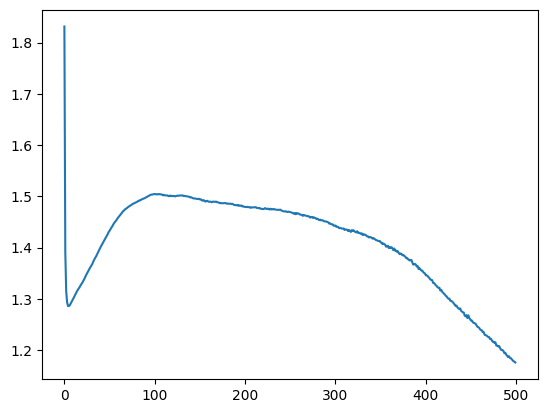

In [ ]:
# Vamos a hacer un plot del loss, a ver qué ha pasado

plt.plot(loss_history)

In [ ]:
model.eval()


X_test_norm = (X - x_mean) / x_std
tensor_X_test = torch.from_numpy(X_test_norm.values).float()


with torch.no_grad():
    y_mlp_norm_pred = model(tensor_X_test)


y_pred = y_mlp_norm_pred.numpy() * y_std + y_mean


y_real = y.values

mse_final = mean_squared_error(y_real, y_pred)

print("-" * 30)
print(f"MSE del modelo Lineal: 0.235")
print(f"MSE de nuestro modelo MLP:        {mse_final:.4f}")
print("-" * 30)



------------------------------
MSE del modelo Lineal: 0.235
MSE de nuestro modelo MLP:        0.0820
------------------------------
